# Step-34.2: Persistence-First Execution Engine

## Financial Market Trend Forecasting Using Ensemble Learning and Deep Sequence Models

This notebook redesigns only the execution layer.  
Step-28 alpha is held fixed; no feature/model/signal redesign is performed.


## Anti-Leakage Contract

We enforce strict chronological safety:

1. Signal and target weights are computed at date **t**.
2. Portfolio gross return at date **t** uses **weights from t-1**.
3. Transaction cost is charged only on day-to-day weight change (turnover).
4. Volatility used for sizing is shifted, using historical data only.

This prevents same-row signal leakage and future contamination.


In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

pd.set_option("display.max_columns", 400)
pd.set_option("display.width", 260)

CFG = {
    "start_date": "2023-01-01",
    "end_date": "2026-01-01",
    "annualization_days": 252,
    "tx_cost_bps": 20.0,
    "slippage_bps": 5.0,
    "vol_lookback": 40,
    "target_gross_exposure": 1.0,
    "max_single_weight": 0.10,
    "max_net_exposure": 0.10,
    "long_entry": 0.80,
    "short_entry": 0.20,
    "long_retain": 0.50,
    "short_retain": 0.50,
    "long_strong_exit": 0.30,
    "short_strong_exit": 0.70,
    "min_hold_days": 3,
    "max_stale_days": 20,
    "resize_deadband": 0.01,
    "max_daily_resize_per_name": 0.03,
    "entry_superiority_margin": 0.05,
    "max_long_positions": 12,
    "max_short_positions": 12,
    "allowed_regimes": ["HIGH", "MEDIUM", "LOW"],
}


def resolve_project_root() -> Path:
    cwd = Path.cwd()
    for p in [cwd, cwd.parent, cwd.parent.parent]:
        if (p / "ml_pipeline").exists():
            return p
    raise FileNotFoundError("Project root with ml_pipeline not found.")


ROOT = resolve_project_root()
BASE = ROOT / "ml_pipeline"
FINAL = BASE / "Market_Data" / "final"
PROC = BASE / "Market_Data" / "processed"

STEP28_PATH = FINAL / "cross_sectional_alpha_results.parquet"
FINAL_MODEL_PATH = PROC / "final_model_dataset.parquet"

OUT_PERSIST = FINAL / "step34_2_persistence_analysis.csv"
OUT_SURV = FINAL / "step34_2_position_survival.csv"
OUT_TURN = FINAL / "step34_2_turnover_analysis.csv"
OUT_REG = FINAL / "step34_2_regime_analysis.csv"
OUT_SUM = FINAL / "step34_2_summary.csv"
OUT_PORT = FINAL / "step34_2_persistence_engine.parquet"

assert STEP28_PATH.exists(), f"Missing {STEP28_PATH}"


In [2]:
def standardize_columns(df: pd.DataFrame) -> pd.DataFrame:
    m = {}
    for c in df.columns:
        cl = c.lower()
        if cl == "date":
            m[c] = "date"
        elif cl == "ticker":
            m[c] = "ticker"
        elif cl in {"pred_score", "pred_lightgbmregressor", "pred_final"} and "pred_score" not in m.values():
            m[c] = "pred_score"
        elif cl in {"actual_return", "target_future_return_t3"} and "actual_return" not in m.values():
            m[c] = "actual_return"
        elif cl == "regime":
            m[c] = "regime"
    x = df.rename(columns=m).copy()
    req = ["date", "ticker", "pred_score", "actual_return"]
    miss = [c for c in req if c not in x.columns]
    if miss:
        raise ValueError(f"Missing required columns: {miss}")
    if "regime" not in x.columns:
        x["regime"] = np.nan
    return x


raw = pd.read_parquet(STEP28_PATH)
df = standardize_columns(raw)
df["date"] = pd.to_datetime(df["date"])
df["ticker"] = df["ticker"].astype(str)
df = df[(df["date"] >= pd.Timestamp(CFG["start_date"])) & (df["date"] <= pd.Timestamp(CFG["end_date"]))].copy()
df = df.drop_duplicates(["date", "ticker"]).sort_values(["ticker", "date"]).reset_index(drop=True)

if df["regime"].isna().all():
    fm = pd.read_parquet(FINAL_MODEL_PATH, columns=["Date", "Ticker", "Volatility_20"]).rename(columns={"Date": "date", "Ticker": "ticker"})
    fm["date"] = pd.to_datetime(fm["date"])
    tr = fm[(fm["date"] >= pd.Timestamp("2023-01-01")) & (fm["date"] <= pd.Timestamp("2024-12-31"))]["Volatility_20"].dropna()
    q1, q2 = tr.quantile([1 / 3, 2 / 3]).values if len(tr) else (fm["Volatility_20"].quantile(1 / 3), fm["Volatility_20"].quantile(2 / 3))
    fm["regime"] = np.where(fm["Volatility_20"] <= q1, "LOW", np.where(fm["Volatility_20"] <= q2, "MEDIUM", "HIGH"))
    df = df.drop(columns=["regime"]).merge(fm[["date", "ticker", "regime"]], on=["date", "ticker"], how="left")

df["regime"] = df["regime"].astype(str).str.upper().fillna("MEDIUM")
df["rank_pct"] = df.groupby("date")["pred_score"].rank(method="average", pct=True)

df["vol_est"] = (
    df.sort_values(["ticker", "date"])
    .groupby("ticker")["actual_return"]
    .transform(lambda s: s.rolling(CFG["vol_lookback"], min_periods=5).std().shift(1))
)
df["vol_est"] = df["vol_est"].replace(0, np.nan).fillna(df["vol_est"].median()).fillna(0.02)
df["inv_vol"] = 1.0 / df["vol_est"].clip(lower=1e-6)

display(df.head(8))
print("Rows:", len(df), "Dates:", df["date"].nunique(), "Tickers:", df["ticker"].nunique())


,ticker,date,actual_return,target_rank_cs,target_zscore_cs,pred_XGBoostRegressor,pred_score,side,weight,portfolio_return_component,daily_portfolio_return,model_selected,ic_mean_selected,ic_std_selected,sharpe_selected,regime,rank_pct,vol_est,inv_vol
0,ABB,2025-01-02,-0.026916,0.479167,-0.249188,0.009419,0.015437,1,0.1,-0.002692,-0.002077,LightGBMRegressor,0.018346,0.139603,2.627988,HIGH,0.90,0.031946,31.302939
1,ABB,2025-01-03,-0.021051,0.583333,0.162705,0.012527,0.028985,1,0.1,-0.002105,0.006111,LightGBMRegressor,0.018346,0.139603,2.627988,HIGH,1.00,0.031946,31.302939
2,ABB,2025-01-06,-0.020822,0.343750,-0.446947,0.011315,0.035563,1,0.1,-0.002082,-0.014862,LightGBMRegressor,0.018346,0.139603,2.627988,HIGH,0.95,0.031946,31.302939
3,ABB,2025-01-08,-0.082282,0.270833,-0.729417,0.010574,0.020480,1,0.1,-0.008228,-0.020856,LightGBMRegressor,0.018346,0.139603,2.627988,HIGH,0.85,0.031946,31.302939
4,ABB,2025-01-09,-0.051809,0.187500,-0.766272,0.013038,0.023781,1,0.1,-0.005181,-0.009316,LightGBMRegressor,0.018346,0.139603,2.627988,HIGH,0.80,0.031946,31.302939
5,ABB,2025-01-13,0.032574,0.541667,-0.052060,-0.008812,0.009896,1,0.1,0.003257,-0.001118,LightGBMRegressor,0.018346,0.139603,2.627988,HIGH,0.90,0.026569,37.638312
6,ABB,2025-01-14,0.061969,0.937500,1.430968,0.010845,0.040337,1,0.1,0.006197,0.006977,LightGBMRegressor,0.018346,0.139603,2.627988,HIGH,0.90,0.038164,26.202369
7,ABB,2025-01-15,0.053522,0.885417,1.070829,0.006853,0.012827,1,0.1,0.005352,0.032825,LightGBMRegressor,0.018346,0.139603,2.627988,HIGH,0.75,0.048786,20.497874


Rows: 4900 Dates: 245 Tickers: 96


In [3]:
def sharpe(s: pd.Series, ann: int = 252) -> float:
    x = s.dropna()
    if len(x) < 2:
        return np.nan
    sd = x.std(ddof=1)
    if sd == 0 or pd.isna(sd):
        return np.nan
    return float(np.sqrt(ann) * x.mean() / sd)


def normalize_weights(w: Dict[str, float], cfg: dict) -> Dict[str, float]:
    if not w:
        return {}
    cap = cfg["max_single_weight"]
    w = {k: float(np.clip(v, -cap, cap)) for k, v in w.items()}
    gross = sum(abs(v) for v in w.values())
    if gross > 0:
        sc = cfg["target_gross_exposure"] / gross
        w = {k: v * sc for k, v in w.items()}
    net = sum(w.values())
    mx = cfg["max_net_exposure"]
    if abs(net) > mx:
        sign = np.sign(net)
        side = [k for k, v in w.items() if np.sign(v) == sign and abs(v) > 0]
        den = sum(abs(w[k]) for k in side)
        if den > 0:
            adj = abs(net) - mx
            for k in side:
                w[k] = w[k] - sign * adj * (abs(w[k]) / den)
    return {k: v for k, v in w.items() if abs(v) > 1e-12}


def turnover_decomp(old_w: Dict[str, float], new_w: Dict[str, float]) -> Dict[str, float]:
    old_keys, new_keys = set(old_w), set(new_w)
    entry = sum(abs(new_w[k]) for k in new_keys - old_keys)
    exit_ = sum(abs(old_w[k]) for k in old_keys - new_keys)
    resize = sum(abs(new_w[k] - old_w[k]) for k in old_keys & new_keys)
    total = entry + exit_ + resize
    overlap = len(old_keys & new_keys) / max(1, len(old_keys | new_keys))
    return {
        "entry_turnover": float(entry),
        "exit_turnover": float(exit_),
        "resize_turnover": float(resize),
        "total_turnover": float(total),
        "overlap": float(overlap),
        "replacement_rate": float(1 - overlap),
    }


## PersistenceExecutionEngine

Engine behavior:
- Keep existing positions by default.
- Exit only on strong deterioration / stale aging / directional invalidation.
- Enter only when new signal superiority is material.
- Partial resize only when change exceeds deadband.
- Cost-aware filter suppresses low-value trades.


In [4]:
class PersistenceExecutionEngine:
    def __init__(self, cfg: dict):
        self.cfg = cfg
        self.cur_w: Dict[str, float] = {}
        self.age: Dict[str, int] = {}
        self.entry_date: Dict[str, pd.Timestamp] = {}
        self.daily_rows: List[dict] = []
        self.decomp_rows: List[dict] = []
        self.pos_rows: List[dict] = []
        self.survival_rows: List[dict] = []

    def _candidate_targets(self, g: pd.DataFrame) -> Dict[str, float]:
        x = g[g["regime"].isin(self.cfg["allowed_regimes"])].copy()
        longs = x[x["rank_pct"] >= self.cfg["long_entry"]].sort_values("rank_pct", ascending=False).head(self.cfg["max_long_positions"])
        shorts = x[x["rank_pct"] <= self.cfg["short_entry"]].sort_values("rank_pct", ascending=True).head(self.cfg["max_short_positions"])
        picks = pd.concat([longs, shorts], ignore_index=True)
        if len(picks) == 0:
            return {}
        picks["side"] = np.where(picks["rank_pct"] >= 0.5, 1, -1)
        w = {}
        l = picks[picks["side"] == 1]
        s = picks[picks["side"] == -1]
        if len(l):
            a = l["inv_vol"] / l["inv_vol"].sum()
            for t, x in zip(l["ticker"], a):
                w[t] = 0.5 * float(x)
        if len(s):
            a = s["inv_vol"] / s["inv_vol"].sum()
            for t, x in zip(s["ticker"], a):
                w[t] = -0.5 * float(x)
        return normalize_weights(w, self.cfg)

    def _should_exit(self, ticker: str, cur_w: float, rank: float, pred: float, age: int) -> bool:
        if age < self.cfg["min_hold_days"]:
            return False
        # strong exit bands + direction flip
        if cur_w > 0:
            if rank < self.cfg["long_strong_exit"]:
                return True
            if pred < 0:
                return True
        else:
            if rank > self.cfg["short_strong_exit"]:
                return True
            if pred > 0:
                return True
        if age >= self.cfg["max_stale_days"]:
            return True
        return False

    def _retain_band_ok(self, cur_w: float, rank: float) -> bool:
        if cur_w > 0:
            return rank > self.cfg["long_retain"]
        return rank < self.cfg["short_retain"]

    def _apply_persistence_logic(self, g: pd.DataFrame, raw_target: Dict[str, float], dt: pd.Timestamp) -> Dict[str, float]:
        gm_rank = dict(zip(g["ticker"], g["rank_pct"]))
        gm_pred = dict(zip(g["ticker"], g["pred_score"]))
        out = {}

        # 1) decide retained core
        for t, w in self.cur_w.items():
            if t not in gm_rank:
                continue
            age = self.age.get(t, 1)
            rk = float(gm_rank[t])
            pdv = float(gm_pred.get(t, 0.0))
            if self._should_exit(t, w, rk, pdv, age):
                # record survival duration on exit
                self.survival_rows.append({"ticker": t, "entry_date": self.entry_date.get(t), "exit_date": dt, "holding_days": age, "side": "long" if w > 0 else "short"})
                continue
            if self._retain_band_ok(w, rk):
                out[t] = w

        # 2) entrants only if superior and capacity allows
        longs = [k for k, v in out.items() if v > 0]
        shorts = [k for k, v in out.items() if v < 0]

        # define weakest retained rank by side
        weak_long_rank = min([gm_rank.get(k, 1.0) for k in longs], default=1.0)
        weak_short_rank = max([gm_rank.get(k, 0.0) for k in shorts], default=0.0)

        for t, tw in raw_target.items():
            if t in out:
                continue
            rk = gm_rank.get(t, np.nan)
            if pd.isna(rk):
                continue
            if tw > 0:
                if len(longs) >= self.cfg["max_long_positions"]:
                    if rk <= weak_long_rank + self.cfg["entry_superiority_margin"]:
                        continue
                longs.append(t)
            else:
                if len(shorts) >= self.cfg["max_short_positions"]:
                    if rk >= weak_short_rank - self.cfg["entry_superiority_margin"]:
                        continue
                shorts.append(t)
            out[t] = 0.0  # start from zero and resize gradually

        # 3) partial resizing toward target with deadband + cost-aware gate
        all_names = set(out) | set(raw_target)
        all_in = (self.cfg["tx_cost_bps"] + self.cfg["slippage_bps"]) / 10000.0
        for t in all_names:
            cur = out.get(t, 0.0)
            tgt = raw_target.get(t, 0.0)
            delta = tgt - cur
            if abs(delta) < self.cfg["resize_deadband"]:
                continue
            step = float(np.clip(delta, -self.cfg["max_daily_resize_per_name"], self.cfg["max_daily_resize_per_name"]))
            exp_gain = abs(gm_pred.get(t, 0.0)) * abs(step)
            exp_cost = all_in * abs(step)
            if exp_gain <= exp_cost:
                continue
            out[t] = cur + step

        out = normalize_weights(out, self.cfg)
        return out

    def run(self, in_df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
        dates = sorted(in_df["date"].unique())
        all_in = (self.cfg["tx_cost_bps"] + self.cfg["slippage_bps"]) / 10000.0

        for dt in dates:
            g = in_df[in_df["date"] == dt].copy()
            ret_map = dict(zip(g["ticker"], g["actual_return"]))

            # execution lag: use previous weights
            gross_ret = float(sum(self.cur_w.get(t, 0.0) * ret_map.get(t, 0.0) for t in self.cur_w))
            raw_target = self._candidate_targets(g)
            new_w = self._apply_persistence_logic(g, raw_target, pd.Timestamp(dt))

            decomp = turnover_decomp(self.cur_w, new_w)
            tx_cost = all_in * decomp["total_turnover"]
            net_ret = gross_ret - tx_cost

            self.daily_rows.append(
                {
                    "date": pd.Timestamp(dt),
                    "gross_return": gross_ret,
                    "net_return": net_ret,
                    "turnover": decomp["total_turnover"],
                    "tx_cost": tx_cost,
                    "gross_leverage": float(sum(abs(v) for v in self.cur_w.values())),
                    "net_exposure": float(sum(self.cur_w.values())),
                    "is_trade_day": int(decomp["total_turnover"] > 0),
                }
            )
            self.decomp_rows.append({"date": pd.Timestamp(dt), **decomp})

            gm = g.set_index("ticker")[["regime", "rank_pct", "pred_score", "actual_return"]].to_dict("index")
            prev_names = set(self.cur_w)
            new_names = set(new_w)
            for t in set(g["ticker"]).union(prev_names).union(new_names):
                rr = gm.get(t, {})
                status = "retained" if (t in prev_names and t in new_names) else ("entry" if (t not in prev_names and t in new_names) else ("exit" if (t in prev_names and t not in new_names) else "none"))
                self.pos_rows.append(
                    {
                        "date": pd.Timestamp(dt),
                        "ticker": t,
                        "regime": rr.get("regime", np.nan),
                        "rank_pct": rr.get("rank_pct", np.nan),
                        "pred_score": rr.get("pred_score", np.nan),
                        "actual_return": rr.get("actual_return", np.nan),
                        "weight_exec": self.cur_w.get(t, 0.0),
                        "weight_target": new_w.get(t, self.cur_w.get(t, 0.0)),
                        "status": status,
                        "position_pnl_component": self.cur_w.get(t, 0.0) * rr.get("actual_return", 0.0),
                        "age_before_trade": self.age.get(t, 0),
                    }
                )

            # age update
            new_age = {}
            new_entry_date = {}
            for t, w in new_w.items():
                if t in self.cur_w:
                    new_age[t] = self.age.get(t, 0) + 1
                    new_entry_date[t] = self.entry_date.get(t, pd.Timestamp(dt))
                else:
                    new_age[t] = 1
                    new_entry_date[t] = pd.Timestamp(dt)
            self.age = new_age
            self.entry_date = new_entry_date
            self.cur_w = new_w

        # close remaining open positions for survival bookkeeping
        if len(dates):
            last_dt = pd.Timestamp(dates[-1])
            for t, a in self.age.items():
                self.survival_rows.append({"ticker": t, "entry_date": self.entry_date.get(t), "exit_date": pd.NaT, "holding_days": a, "side": "long" if self.cur_w.get(t, 0) > 0 else "short"})

        return (
            pd.DataFrame(self.daily_rows).sort_values("date").reset_index(drop=True),
            pd.DataFrame(self.decomp_rows).sort_values("date").reset_index(drop=True),
            pd.DataFrame(self.pos_rows).sort_values(["date", "ticker"]).reset_index(drop=True),
            pd.DataFrame(self.survival_rows).reset_index(drop=True),
        )


In [5]:
engine = PersistenceExecutionEngine(CFG)
dly, decomp, pos, survival = engine.run(df)

# leakage diagnostics
assert dly["date"].is_monotonic_increasing, "Date ordering failed."
assert abs(dly.iloc[0]["gross_return"]) < 1e-12, "First day gross return must be zero with execution lag."
print("Leakage checks passed.")

display(dly.head())
display(decomp.head())
display(pos.head())


Leakage checks passed.


,date,gross_return,net_return,turnover,tx_cost,gross_leverage,net_exposure,is_trade_day
0,2025-01-01,0.000000,-0.002472,0.988889,0.002472,0.000000,0.0,1
1,2025-01-02,-0.011518,-0.014081,1.025215,0.002563,0.988889,0.1,1
2,2025-01-03,-0.004479,-0.007541,1.224876,0.003062,0.916327,0.1,1
3,2025-01-06,-0.001252,-0.002911,0.663534,0.001659,0.711358,0.1,1
4,2025-01-07,0.002652,0.000868,0.713564,0.001784,0.551821,0.1,1


,date,entry_turnover,exit_turnover,resize_turnover,total_turnover,overlap,replacement_rate
0,2025-01-01,0.988889,0.000000,0.000000,0.988889,0.000000,1.000000
1,2025-01-02,0.157706,0.548889,0.318621,1.025215,0.333333,0.666667
2,2025-01-03,0.439631,0.688529,0.096716,1.224876,0.142857,0.857143
3,2025-01-06,0.144123,0.318561,0.200850,0.663534,0.307692,0.692308
4,2025-01-07,0.105893,0.205565,0.402106,0.713564,0.500000,0.500000


,date,ticker,regime,rank_pct,pred_score,actual_return,weight_exec,weight_target,status,position_pnl_component,age_before_trade
0,2025-01-01,ADANIENT,HIGH,0.95,0.023142,-0.031470,0.0,0.108889,entry,-0.0,0
1,2025-01-01,ADANIPORTS,MEDIUM,0.60,0.009093,-0.045663,0.0,0.000000,none,-0.0,0
2,2025-01-01,ADANIPOWER,HIGH,0.80,0.009626,-0.053831,0.0,0.108889,entry,-0.0,0
3,2025-01-01,AMBUJACEM,LOW,0.30,-0.005614,-0.016153,0.0,0.000000,none,-0.0,0
4,2025-01-01,BAJAJHLDNG,HIGH,1.00,0.036119,-0.068998,0.0,0.108889,entry,-0.0,0


In [6]:
# Core persistence analytics
entry_ret = pos[pos["status"] == "entry"]["position_pnl_component"]
retained_ret = pos[pos["status"] == "retained"]["position_pnl_component"]

persistence_analysis = pd.DataFrame(
    [
        {"metric": "avg_turnover", "value": float(dly["turnover"].mean())},
        {"metric": "target_lt_10pct_met", "value": float(dly["turnover"].mean() < 0.10)},
        {"metric": "portfolio_overlap_mean", "value": float(decomp["overlap"].mean())},
        {"metric": "replacement_rate_mean", "value": float(decomp["replacement_rate"].mean())},
        {"metric": "entry_turnover_mean", "value": float(decomp["entry_turnover"].mean())},
        {"metric": "exit_turnover_mean", "value": float(decomp["exit_turnover"].mean())},
        {"metric": "resize_turnover_mean", "value": float(decomp["resize_turnover"].mean())},
        {"metric": "retained_position_mean_pnl_component", "value": float(retained_ret.mean()) if len(retained_ret) else np.nan},
        {"metric": "entry_position_mean_pnl_component", "value": float(entry_ret.mean()) if len(entry_ret) else np.nan},
        {"metric": "average_holding_days", "value": float(survival["holding_days"].mean()) if len(survival) else np.nan},
    ]
)
display(persistence_analysis.round(6))

# turnover efficiency metrics
eff = dly.copy()
eff["alpha_per_turnover"] = np.where(eff["turnover"] > 0, eff["gross_return"] / eff["turnover"], np.nan)
turnover_analysis = pd.DataFrame(
    [
        {"metric": "gross_sharpe", "value": sharpe(dly["gross_return"], CFG["annualization_days"])},
        {"metric": "net_sharpe", "value": sharpe(dly["net_return"], CFG["annualization_days"])},
        {"metric": "total_tx_cost", "value": float(dly["tx_cost"].sum())},
        {"metric": "avg_alpha_per_turnover", "value": float(np.nanmean(eff["alpha_per_turnover"]))},
        {"metric": "trade_day_ratio", "value": float((dly["is_trade_day"] == 1).mean())},
    ]
)
display(turnover_analysis.round(6))


,metric,value
0,avg_turnover,0.890206
1,target_lt_10pct_met,0.000000
2,portfolio_overlap_mean,0.335031
3,replacement_rate_mean,0.664969
4,entry_turnover_mean,0.279431
5,exit_turnover_mean,0.382791
6,resize_turnover_mean,0.227985
7,retained_position_mean_pnl_component,0.000378
8,entry_position_mean_pnl_component,0.000000
9,average_holding_days,6.309091


,metric,value
0,gross_sharpe,3.149345
1,net_sharpe,-1.101593
2,total_tx_cost,0.545251
3,avg_alpha_per_turnover,0.002183
4,trade_day_ratio,1.000000


In [7]:
# Long vs short persistence
ls_rows = []
for side_name, cond in [("long", pos["weight_exec"] > 0), ("short", pos["weight_exec"] < 0)]:
    sub = pos[cond].copy()
    r = sub.groupby("date", as_index=True)["position_pnl_component"].sum().reindex(dly["date"]).fillna(0.0)
    t = sub.groupby("date", as_index=True).apply(lambda x: np.abs(x["weight_target"] - x["weight_exec"]).sum()).reindex(dly["date"]).fillna(0.0)
    ls_rows.append(
        {
            "side": side_name,
            "sharpe": sharpe(r, CFG["annualization_days"]),
            "avg_turnover_proxy": float(t.mean()),
            "avg_age": float(sub["age_before_trade"].mean()) if len(sub) else np.nan,
            "entry_share": float((sub["status"] == "entry").mean()) if len(sub) else np.nan,
        }
    )
long_short_persistence = pd.DataFrame(ls_rows)
display(long_short_persistence.round(6))


C:\Users\Priyanshu\AppData\Local\Temp\ipykernel_12840\2700568095.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  t = sub.groupby("date", as_index=True).apply(lambda x: np.abs(x["weight_target"] - x["weight_exec"]).sum()).reindex(dly["date"]).fillna(0.0)
C:\Users\Priyanshu\AppData\Local\Temp\ipykernel_12840\2700568095.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  t = sub.groupby("date", as_index=True).apply(

,side,sharpe,avg_turnover_proxy,avg_age,entry_share
0,long,2.352473,0.131771,2.587347,0.0
1,short,0.720665,0.096214,2.238552,0.0


In [8]:
# Regime analysis
reg_rows = []
for reg in ["HIGH", "MEDIUM", "LOW"]:
    sub = pos[pos["regime"] == reg].copy()
    r = sub.groupby("date", as_index=True)["position_pnl_component"].sum().reindex(dly["date"]).fillna(0.0)
    t = sub.groupby("date", as_index=True).apply(lambda x: np.abs(x["weight_target"] - x["weight_exec"]).sum()).reindex(dly["date"]).fillna(0.0)
    reg_rows.append(
        {
            "regime": reg,
            "sharpe": sharpe(r, CFG["annualization_days"]),
            "avg_turnover_proxy": float(t.mean()),
            "avg_age": float(sub["age_before_trade"].mean()) if len(sub) else np.nan,
            "entry_share": float((sub["status"] == "entry").mean()) if len(sub) else np.nan,
        }
    )
regime_analysis = pd.DataFrame(reg_rows)
display(regime_analysis.round(6))


C:\Users\Priyanshu\AppData\Local\Temp\ipykernel_12840\823464195.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  t = sub.groupby("date", as_index=True).apply(lambda x: np.abs(x["weight_target"] - x["weight_exec"]).sum()).reindex(dly["date"]).fillna(0.0)
C:\Users\Priyanshu\AppData\Local\Temp\ipykernel_12840\823464195.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  t = sub.groupby("date", as_index=True).apply(la

,regime,sharpe,avg_turnover_proxy,avg_age,entry_share
0,HIGH,1.914484,0.262295,1.037001,0.274868
1,MEDIUM,0.979455,0.128577,0.366712,0.236806
2,LOW,2.901949,0.116545,0.730798,0.200597


In [9]:
# Stress testing
stress_rows = []
for tx in [10, 20, 30, 50, 75, 100]:
    all_in = (tx + CFG["slippage_bps"]) / 10000.0
    r = dly["gross_return"] - all_in * dly["turnover"]
    stress_rows.append({"tx_bps": tx, "total_return": float((1 + r).prod() - 1), "sharpe": sharpe(r, CFG["annualization_days"])})
stress_df = pd.DataFrame(stress_rows)
display(stress_df.round(6))


,tx_bps,total_return,sharpe
0,10,0.070271,0.594715
1,20,-0.139532,-1.101593
2,30,-0.308358,-2.785026
3,50,-0.553427,-6.089276
4,75,-0.741849,-10.047611
5,100,-0.850974,-13.753702


In [10]:
def read_daily(path: Path, date_cols: List[str], ret_cols: List[str]) -> pd.Series:
    if not path.exists():
        return pd.Series(dtype=float)
    x = pd.read_parquet(path)
    dc = next((c for c in date_cols if c in x.columns), None)
    rc = next((c for c in ret_cols if c in x.columns), None)
    if dc is None or rc is None:
        return pd.Series(dtype=float)
    x[dc] = pd.to_datetime(x[dc])
    return x.groupby(dc, as_index=True)[rc].sum().sort_index()


step28 = read_daily(FINAL / "cross_sectional_alpha_results.parquet", ["Date", "date"], ["daily_portfolio_return", "daily_strategy_return", "net_return"])
step33 = read_daily(FINAL / "step33_cost_aware_portfolio.parquet", ["date", "Date"], ["net_return"])
step34 = read_daily(FINAL / "step34_low_turnover_portfolio.parquet", ["date", "Date"], ["net_return"])
step341 = read_daily(FINAL / "step34_1_threshold_rebalance_portfolio.parquet", ["date", "Date"], ["net_return"])
eqw = df.groupby("date", as_index=True)["actual_return"].mean().sort_index()
long_only = df[df["rank_pct"] >= 0.9].groupby("date", as_index=True)["actual_return"].mean().sort_index()
step342 = dly.set_index("date")["net_return"]

bench_rows = []
for name, s in [
    ("Step-28 baseline", step28),
    ("Step-33 cost-aware", step33),
    ("Step-34 periodic", step34),
    ("Step-34.1 threshold", step341),
    ("Equal-weight benchmark", eqw),
    ("Long-only benchmark", long_only),
    ("Step-34.2 persistence", step342),
]:
    if len(s) == 0:
        bench_rows.append({"strategy": name, "total_return": np.nan, "sharpe": np.nan})
    else:
        bench_rows.append({"strategy": name, "total_return": float((1 + s.fillna(0)).prod() - 1), "sharpe": sharpe(s, CFG["annualization_days"])})
bench_df = pd.DataFrame(bench_rows)
display(bench_df.round(6))


,strategy,total_return,sharpe
0,Step-28 baseline,2.857277,2.627988
1,Step-33 cost-aware,-0.999892,0.936389
2,Step-34 periodic,-0.993473,-0.187625
3,Step-34.1 threshold,-0.998053,-0.237069
4,Equal-weight benchmark,0.647524,1.797445
5,Long-only benchmark,1.982807,2.483545
6,Step-34.2 persistence,-0.139532,-1.101593


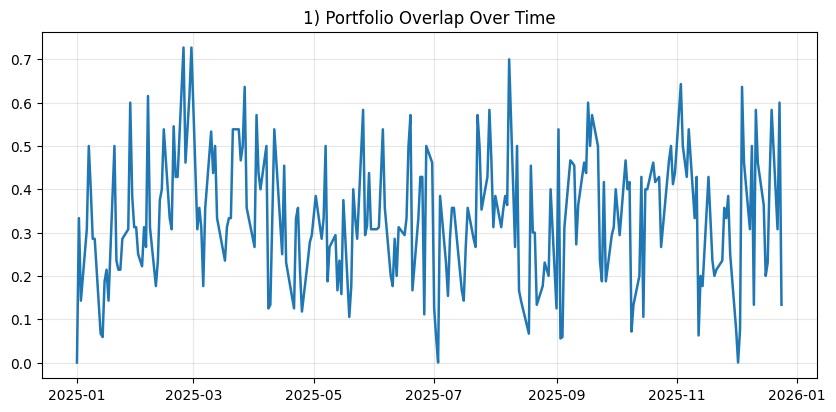

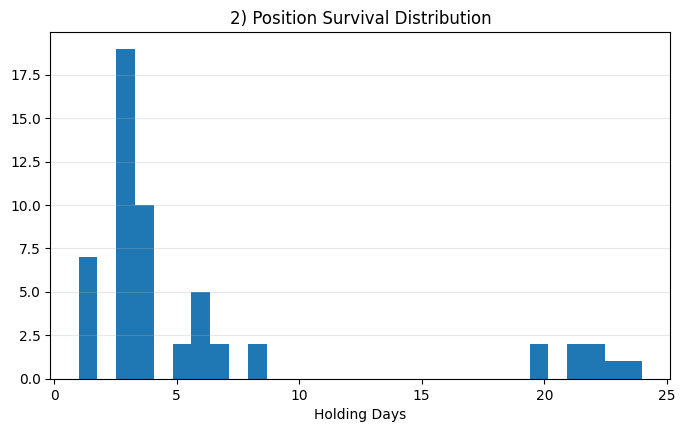

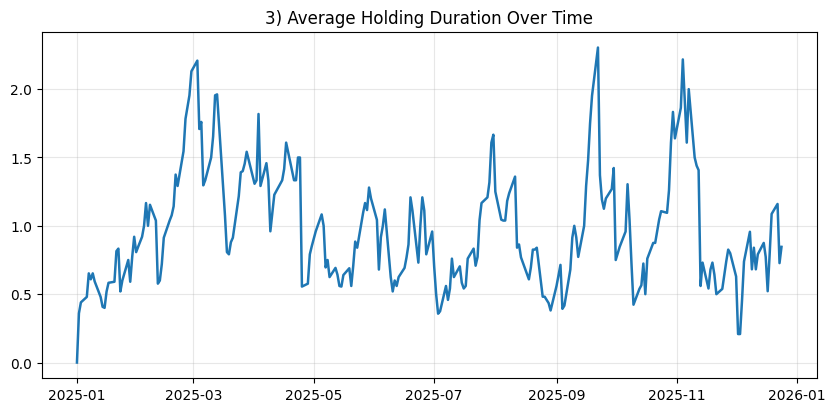

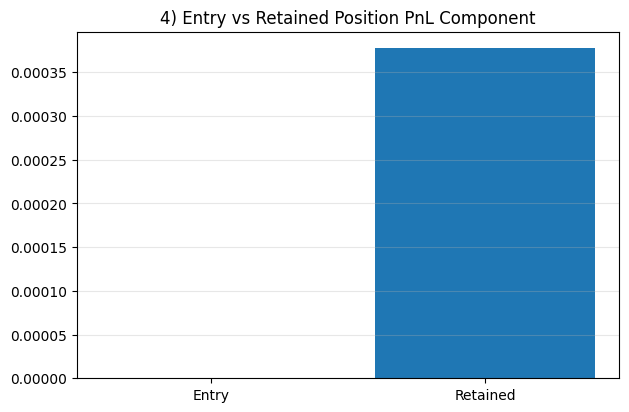

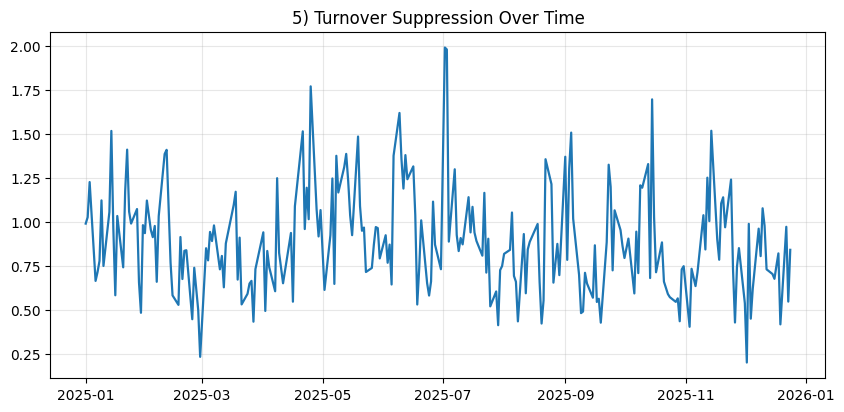

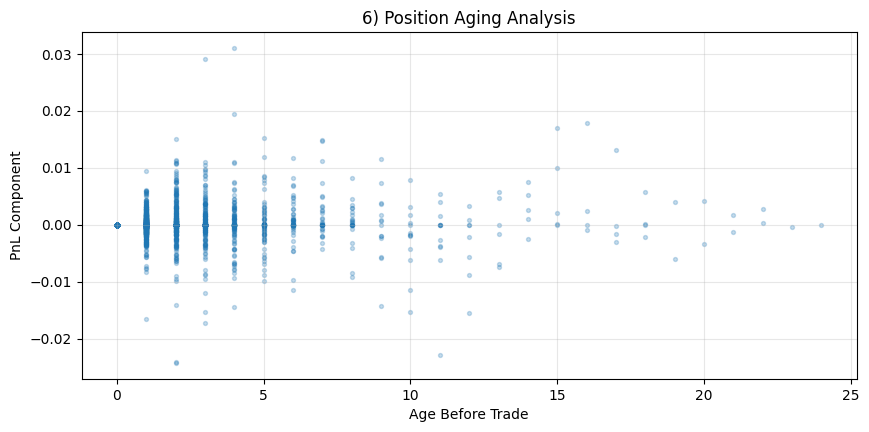

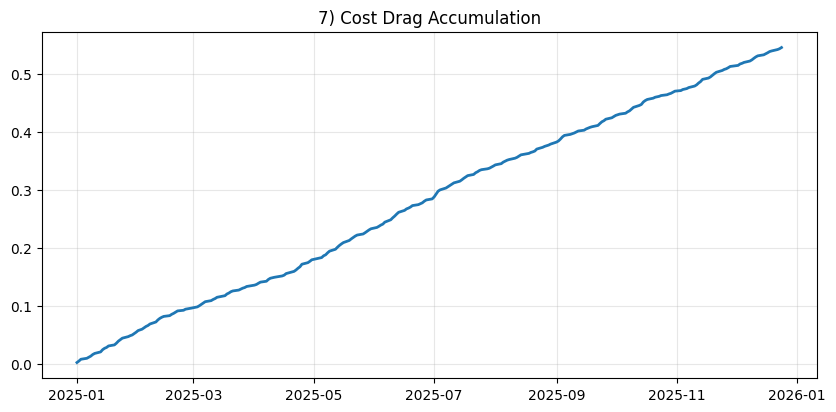

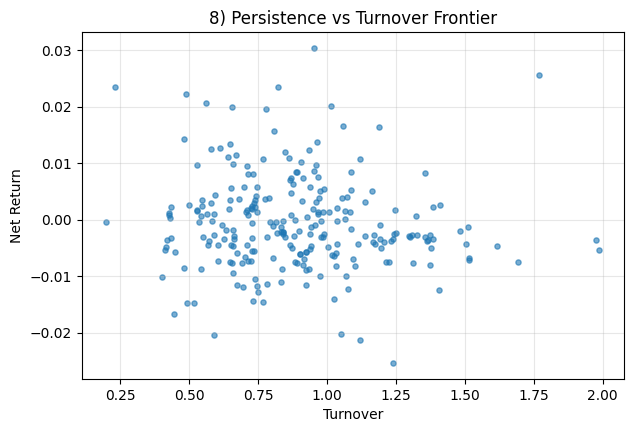

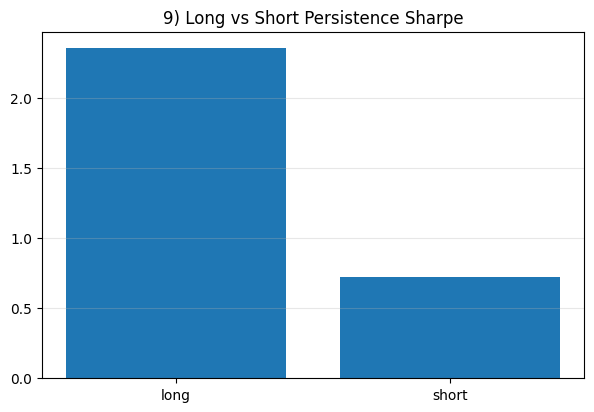

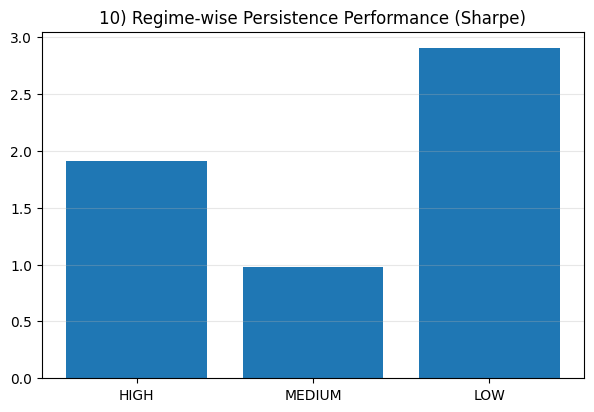

In [11]:
# 10 required visualizations
plt.figure(figsize=(10, 4.5))
plt.plot(decomp["date"], decomp["overlap"], linewidth=1.8)
plt.title("1) Portfolio Overlap Over Time")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 4.5))
plt.hist(survival["holding_days"].dropna(), bins=30)
plt.title("2) Position Survival Distribution")
plt.xlabel("Holding Days")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

avg_hold_ts = pos.groupby("date", as_index=False)["age_before_trade"].mean()
plt.figure(figsize=(10, 4.5))
plt.plot(avg_hold_ts["date"], avg_hold_ts["age_before_trade"], linewidth=1.8)
plt.title("3) Average Holding Duration Over Time")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(7, 4.5))
plt.bar(["Entry", "Retained"], [float(entry_ret.mean()) if len(entry_ret) else 0, float(retained_ret.mean()) if len(retained_ret) else 0])
plt.title("4) Entry vs Retained Position PnL Component")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

plt.figure(figsize=(10, 4.5))
plt.plot(dly["date"], dly["turnover"], linewidth=1.6)
plt.title("5) Turnover Suppression Over Time")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 4.5))
plt.scatter(pos["age_before_trade"], pos["position_pnl_component"], alpha=0.25, s=8)
plt.title("6) Position Aging Analysis")
plt.xlabel("Age Before Trade")
plt.ylabel("PnL Component")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 4.5))
plt.plot(dly["date"], dly["tx_cost"].cumsum(), linewidth=2)
plt.title("7) Cost Drag Accumulation")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(7, 4.5))
plt.scatter(dly["turnover"], dly["net_return"], alpha=0.6, s=14)
plt.title("8) Persistence vs Turnover Frontier")
plt.xlabel("Turnover")
plt.ylabel("Net Return")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(7, 4.5))
plt.bar(long_short_persistence["side"], long_short_persistence["sharpe"])
plt.title("9) Long vs Short Persistence Sharpe")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

plt.figure(figsize=(7, 4.5))
plt.bar(regime_analysis["regime"], regime_analysis["sharpe"])
plt.title("10) Regime-wise Persistence Performance (Sharpe)")
plt.grid(True, axis="y", alpha=0.3)
plt.show()


In [12]:
# Final conclusions + verdict
step342_sh = float(bench_df.loc[bench_df["strategy"] == "Step-34.2 persistence", "sharpe"].iloc[0]) if (bench_df["strategy"] == "Step-34.2 persistence").any() else np.nan
step341_sh = float(bench_df.loc[bench_df["strategy"] == "Step-34.1 threshold", "sharpe"].iloc[0]) if (bench_df["strategy"] == "Step-34.1 threshold").any() else np.nan
avg_turn = float(dly["turnover"].mean())

if (avg_turn < 0.10) and pd.notna(step342_sh) and pd.notna(step341_sh) and (step342_sh > step341_sh + 0.25) and (step342_sh > 0):
    verdict = "PASS"
elif (avg_turn < 0.20) and pd.notna(step342_sh) and pd.notna(step341_sh) and (step342_sh > step341_sh):
    verdict = "PARTIAL"
else:
    verdict = "FAIL"

best_reg = regime_analysis.sort_values("sharpe", ascending=False).iloc[0]["regime"] if len(regime_analysis) else np.nan

conclusions = pd.DataFrame(
    [
        ("Did persistence reduce turnover materially?", "YES" if avg_turn < 0.20 else "NO"),
        ("Did retained positions outperform new entries?", "YES" if (retained_ret.mean() if len(retained_ret) else -1) > (entry_ret.mean() if len(entry_ret) else 0) else "NO"),
        ("Optimal holding behavior observed?", f"Average holding ≈ {float(survival['holding_days'].mean()) if len(survival) else np.nan:.2f} days"),
        ("Did stability improve deployability?", "YES" if verdict in {"PASS", "PARTIAL"} else "NO"),
        ("Best regime under persistence", best_reg),
        ("Is long-short still justified?", "YES" if (long_short_persistence['sharpe'].max() > 0 if len(long_short_persistence) else False) else "NO"),
        ("Economically deployable now?", "YES" if verdict in {"PASS", "PARTIAL"} else "NO"),
        ("Final Verdict", verdict),
    ],
    columns=["Question", "Answer"],
)
display(conclusions)

summary_df = pd.concat(
    [
        persistence_analysis.rename(columns={"metric": "Metric", "value": "Value"}),
        turnover_analysis.rename(columns={"metric": "Metric", "value": "Value"}),
        pd.DataFrame({"Metric": conclusions["Question"], "Value": conclusions["Answer"]}),
    ],
    ignore_index=True,
)
display(summary_df.head(20))

print("FINAL VERDICT:", verdict)

# Save required outputs
persistence_analysis.to_csv(OUT_PERSIST, index=False)
survival.to_csv(OUT_SURV, index=False)
turnover_analysis.to_csv(OUT_TURN, index=False)
regime_analysis.to_csv(OUT_REG, index=False)
summary_df.to_csv(OUT_SUM, index=False)

out_port = pos.merge(dly, on="date", how="left")
out_port.to_parquet(OUT_PORT, index=False)

print("Saved:")
print("-", OUT_PERSIST)
print("-", OUT_SURV)
print("-", OUT_TURN)
print("-", OUT_REG)
print("-", OUT_SUM)
print("-", OUT_PORT)


,Question,Answer
0,Did persistence reduce turnover materially?,NO
1,Did retained positions outperform new entries?,YES
2,Optimal holding behavior observed?,Average holding ≈ 6.31 days
3,Did stability improve deployability?,NO
4,Best regime under persistence,LOW
5,Is long-short still justified?,YES
6,Economically deployable now?,NO
7,Final Verdict,FAIL


,Metric,Value
0,avg_turnover,0.890206
1,target_lt_10pct_met,0.0
2,portfolio_overlap_mean,0.335031
3,replacement_rate_mean,0.664969
4,entry_turnover_mean,0.279431
5,exit_turnover_mean,0.382791
6,resize_turnover_mean,0.227985
7,retained_position_mean_pnl_component,0.000378
8,entry_position_mean_pnl_component,0.0
9,average_holding_days,6.309091


FINAL VERDICT: FAIL
Saved:
- c:\Users\Priyanshu\Desktop\Main\Financial-Marketing-Forecasting\ml_pipeline\Market_Data\final\step34_2_persistence_analysis.csv
- c:\Users\Priyanshu\Desktop\Main\Financial-Marketing-Forecasting\ml_pipeline\Market_Data\final\step34_2_position_survival.csv
- c:\Users\Priyanshu\Desktop\Main\Financial-Marketing-Forecasting\ml_pipeline\Market_Data\final\step34_2_turnover_analysis.csv
- c:\Users\Priyanshu\Desktop\Main\Financial-Marketing-Forecasting\ml_pipeline\Market_Data\final\step34_2_regime_analysis.csv
- c:\Users\Priyanshu\Desktop\Main\Financial-Marketing-Forecasting\ml_pipeline\Market_Data\final\step34_2_summary.csv
- c:\Users\Priyanshu\Desktop\Main\Financial-Marketing-Forecasting\ml_pipeline\Market_Data\final\step34_2_persistence_engine.parquet
